In [74]:
%reset -f

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib import cm
from matplotlib.colors import Normalize 
from matplotlib import colors as mcolors
import matplotlib.style as style 
style.use('seaborn-colorblind')

from sklearn.linear_model import HuberRegressor
from scipy import stats
from scipy.interpolate import interpn

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('mode.chained_assignment', None)
plt.rcParams['savefig.dpi'] = 310
plt.rcParams['font.family'] = 'Arial'

root_dir = '/Volumes/Elements/Ginsburg/WUE/'
os.chdir(root_dir)

pd.set_option('mode.chained_assignment', None)
plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['font.size'] = 11

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

/var/folders/17/m2hbh37n5h71bqc9bp3sk5h00000gn/T/ipykernel_26775/3742466222.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  style.use('seaborn-colorblind')


## necessary functions

In [2]:
def differencing_method_analysis_plot(x, y, s, cmap='magma', ax=None, fig=None, 
                                      sort=True, bins=20, diag_line=True,
                                      reg_line=False, **kwargs):
    
    '''
    This function is used to implement the differencing method, i.e., to plot the scatter of (y2 - y1) vs CO2,
    and fit the regression line to obtain the beta & SNR values
    '''

    if ax is None:
        fig , ax = plt.subplots()
        
    data , x_e, y_e = np.histogram2d( x, y, bins = bins, density = True )
    z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ), data , 
                np.vstack([x,y]).T , method = "splinef2d", bounds_error = False)

    # To be sure to plot all data
    z[np.where(np.isnan(z))] = 0.0

    # Sort the points by density, so that the densest points are plotted last
    if sort :
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    im = ax.scatter(x, y, c=z, s=s, cmap=cmap, **kwargs )
    
    # add the colorbar
    norm = Normalize(vmin = np.min(z), vmax = np.max(z))
    cbar = fig.colorbar(cm.ScalarMappable(norm = norm,cmap=cmap), ax=ax)
    cbar.ax.set_ylabel('Density')
    cbar.formatter.set_powerlimits((0, 0))
    cbar.ax.yaxis.set_offset_position('left')                         
    cbar.update_ticks()
    
    # add the values of metrics
    # regression & regression line
    slope, intercept= fit_regression(x,y)

    # add the diagonal line
    min_x, max_x = ax.get_xlim()
    min_y, max_y = ax.get_ylim()

    max_value = max(max_x,max_y)
    min_value = min(min_x,min_y)
        
    line = np.linspace(min_value, max_value, 100)
    if diag_line:
        ax.plot(line, line,'--',color='black')
    
    x_range = np.linspace(min_x, max_x, 100)
    y_pre = x_range*slope+intercept
    if reg_line:
        ax.plot(x_range, y_pre,color='black')
    
    return ax,slope,intercept,cbar,im


from scipy.optimize import minimize
# Define the loss function
def loss(params, X, y):
    w, b = params
    y_pred = w * X + b
    loss = np.mean(np.abs(y-y_pred))
    return loss

def fit_regression(X,y):
    # Initial guess for parameters
    initial_params = np.array([0.0, 0.0])
    
    # Perform optimization using L1 norm
    result = minimize(loss, initial_params, args=(X, y))
    
    # Extract optimized parameters
    optimal_params = result.x
    slope, intercept = optimal_params
    
    return slope,intercept

In [3]:
def calulate_SNR(y,data,slope,x_var='CO2'):
    
    delta_x   = data[x_var].max() - data[x_var].min()
    y_detrend = detrend_y(y)
    y_std     = y_detrend.std()
    
    SNR = slope*delta_x/y_std
    return SNR, y_std


def calculate_beta_factor(data_full,CO2_var,target,slope):

    CO2_mean = data_full[CO2_var].mean()
    y_mean   = data_full[target].mean()
    
    CO2_e = np.nanquantile(data_full[CO2_var],0.9)
    CO2_a = np.nanquantile(data_full[CO2_var],0.1)
    
    y_e  = y_mean + slope*(CO2_e - CO2_mean)
    y_a  = y_mean + slope*(CO2_a - CO2_mean)
    
    beta = np.log(y_e/y_a)/np.log(CO2_e/CO2_a)

    return beta

def detrend_y(y):
    x   = np.arange(len(y))
    slope, intercept, _, _, _ = stats.linregress(x, y)
    y_pre     = x*slope + intercept
    y_detrend = y - y_pre
    
    return y_detrend

## define basic settings

In [4]:
# basic setting for the analysis (target variable, GPP partitioning method)
target      = 'iWUE' 
choice      = 'DT'
GPP_var     = '_'.join(['GPP',choice])

# meta information
df_site    = pd.read_csv('./Data/results/sites_meta_info.csv',index_col=0)

# input directory
meteo_dir  =  './Data/Ameri_Oz_FN_BASE/daily/meteo_wholeyear/'
WUE_dir    = f'./Data/Ameri_Oz_FN_BASE/daily/WUE/{GPP_var}/'
Gc_dir     =  './Data/Ameri_Oz_FN_BASE/daily/eco_resistance/Rs_MOST/'

# output directory 
target_dir  = f'daily_{target}_NAN'
new_sub_dir = '_'.join([GPP_var,'given_LAISWC_choice'])

# dictionary for relevant variables
vars_dic = {'GPP':['Tair','RH','SW','LAI','WS','SWC','CAMS_CO2'],
            'iWUE':['Tair','RH','SW','LAI','WS','SWC','CAMS_CO2'],
            'Gc':['Tair','RH','SW','LAI','WS','SWC','CAMS_CO2']}

# dictionary for needed predictors for ML models
pred_dic = {'GPP':['Tair','RH','SW','LAI','WS','SWC'],  
            'iWUE':['Tair','RH','SW','LAI','WS','SWC'],
            'Gc':['Tair','RH','SW','LAI','WS','SWC']} 

predictors = pred_dic[target]

## The differencing method: a site example 

In [5]:
# import site-specific meta information 
sitecode             = 'US-Ho1'
LAI_var,SWC_var      = df_site.loc[sitecode,'choice'].split('-')
Canopy_h             = df_site.loc[sitecode,'Canopy_h']
PFT                  = df_site.loc[sitecode,'Cover_type']
CO2_var              = df_site.loc[sitecode,'CO2_source'] 
flag_GS_method       = df_site.loc[sitecode,'flag_GS_method']

In [6]:
# ------------- prepare model inputs --------------
# ----------------- import data -------------------
# import meteo + carbon + water fluxes data
data   = pd.read_csv(os.path.join(meteo_dir,sitecode+'.csv'),index_col=0,parse_dates=True)
data   = data.rename(columns={'SWC':'insitu_SWC'})

# include iWUE data
df_WUE = pd.read_csv(os.path.join(WUE_dir,sitecode+'.csv'),index_col=0,parse_dates=True)
data   = pd.merge(data,df_WUE[['iWUE','iWUE_outlier']],left_index=True,right_index=True,how='left')
data['iWUE'][data['iWUE_outlier']==True] = np.nan 

data['SWC'] = data[SWC_var].values
data['LAI'] = data[LAI_var].values   
data['GPP'] = data[GPP_var].values
data['RH']  = data['RH_cal'].values # note: here we recalculate RH based the given VPD (as some sites show long gaps in their original RH records) 

# data_withNAN: this dataframe contains NAN values in both target & predictors
data_withNAN = data.copy()

# -------------- select growing season & remove NAN values ---------------
# select growing season (GS)
if flag_GS_method==0: # continuous GS flag
    data_GS = data[(data['flag_GS_cont'+'_'+choice]==1)]
else:  # discrete GS flag 
    data_GS = data[(data['flag_GS'+'_'+choice]==1)]

# remove NAN values (taken account of both predictors & target)
var_s          = [target] + vars_dic[target]
df_control_NAN = data_GS[var_s].astype('float32')
noSWC_vars     = [item for item in var_s if item not in ['SWC']] 
nonan_y_index  = df_control_NAN[noSWC_vars].dropna().index.tolist()
df_control_NAN = df_control_NAN[df_control_NAN.index.isin(nonan_y_index)]

# model_input = df_control_NAN.copy()

In [7]:
# ---------------- load ML models ----------------
trained_model_dir = f'./Data/XGBoost/Models/{target_dir}/RH_{CO2_var}_compare/Ameri_Oz_FN_BASE/{new_sub_dir}/'

# model
## model w/o CO2: f1(climate inputs, LAI)
model_path_noCO2 = os.path.join(trained_model_dir,target+'_'+sitecode+'_noCO2.json')
model_noCO2 = xgb.XGBRegressor()
model_noCO2.load_model(model_path_noCO2)

## with CO2: f2(climate inputs, LAI, CO2)
model_path_CO2 = os.path.join(trained_model_dir,target+'_'+sitecode+'_CO2.json')
model_CO2 = xgb.XGBRegressor()
model_CO2.load_model(model_path_CO2)

# ------------- differencing method --------------
data_diff = data_GS.copy()
noSWC_vars  = [item for item in (predictors+[CO2_var]) if item not in ['SWC']] 
noNAN_index = data_diff[noSWC_vars].dropna().index.tolist()
data_diff   = data_diff[data_diff.index.isin(noNAN_index)]

#----------- calculate the difference between f2 and f1 ------------
# f1 model estimates (w/o CO2 as input)
X1        = data_diff[predictors]
y_hat1    = model_noCO2.predict(X1)
# f2 model estimates (with CO2 as input)
X2        = data_diff[predictors+[CO2_var]]
y_hat2    = model_CO2.predict(X2)

# difference
epsilon   = y_hat2 - y_hat1

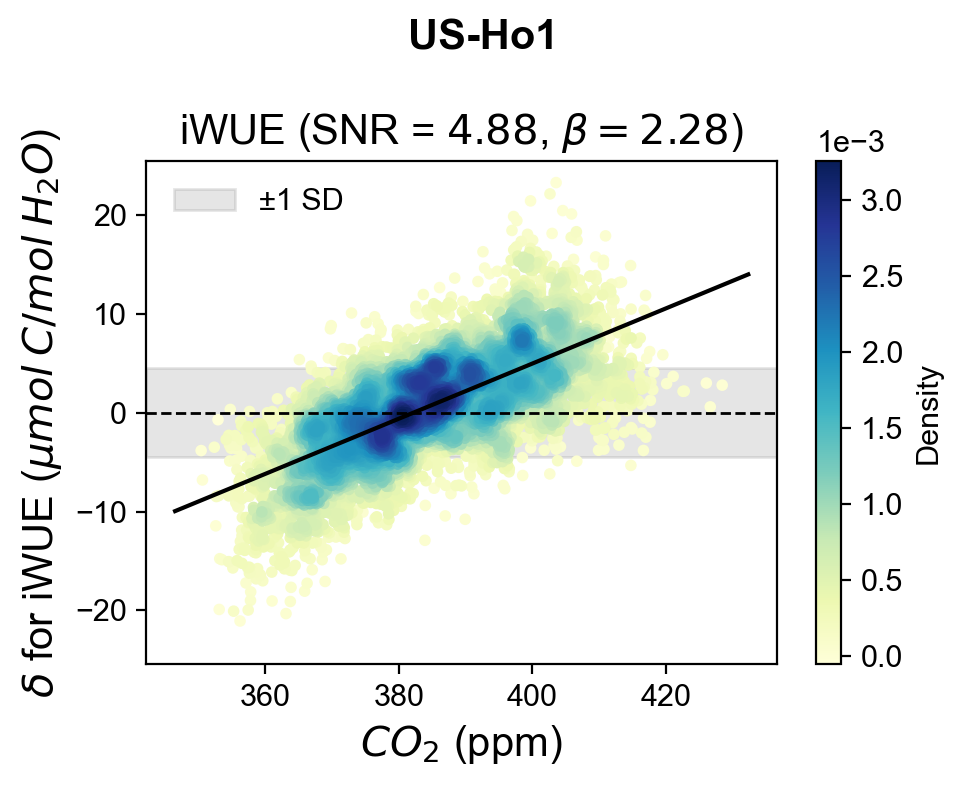

In [8]:
#------------- plot - put option1 & 2 together--------------
fig, ax = plt.subplots(figsize=(5,4))

nonan_idx = (~data_diff[CO2_var].isna()).values
_,slope,intercept,_,_ = differencing_method_analysis_plot(data_diff[CO2_var][nonan_idx],epsilon[nonan_idx],s=10,
                                                          cmap='YlGnBu',ax=ax,fig=fig,
                                                          sort=True,bins=[30,30],diag_line=False,reg_line=True)                                                             
                                                               

# calculate the signal/noise metric
SNR,std = calulate_SNR(epsilon,data_diff,slope,x_var=CO2_var)

# calculate the beta factor
beta = calculate_beta_factor(data_diff,CO2_var,target,slope)

# set labels & titles
yabs_max = abs(max(ax.get_ylim(), key=abs))
ax.set_ylim(ymin=-yabs_max, ymax=yabs_max)

subtitle   = 'SNR = ${%.2f}$'%(SNR)+', '+r'$\beta = {%.2f}$'%(beta)
ylabel_dic = {'GPP':'$\mu mol\,m^{-2}\,s^{-1}$',
              'iWUE':'$\mu mol\:C/mol\:H_{2}O$',
              'Gc':'$mol\,m^{-2}\,s^{-1}$'} # 

ax.set_ylabel(f'$\delta$ for {target} ({ylabel_dic[target]})',fontsize=15) 
ax.set_xlabel('$CO_2$ (ppm)',fontsize=15)
ax.set_title(f'{target} ({subtitle})',fontsize=15)

ax.axhline(0, color='black',linestyle='--' ,linewidth=1)
ax.axhspan(-std, std, color='gray', alpha=0.2, label='±1 SD',zorder=0)
ax.legend()

fig.suptitle(f'{sitecode}',fontsize=15,fontweight='bold')

plt.tight_layout()